In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,r2_score,mean_absolute_error,mean_squared_error)

In [3]:
df = pd.read_csv(
    r"C:\Users\shrey\OneDrive\Desktop\ds ml\spam.csv",
    encoding='latin1'
)


In [4]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [7]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [10]:
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
print("Shape:", df.shape)

df.info()

df.describe(include='all')

Shape: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [13]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [17]:
"Duplicates:", df.duplicated().sum()

('Duplicates:', np.int64(403))

In [18]:
df = df.drop_duplicates()

In [19]:
df['label'] = df['label'].map({ 'ham':0,'spam':1})
df['label'].unique()

array([0, 1])

In [20]:
df['char_count'] = df['message'].apply(len)

df['word_count'] = df['message'].apply(
    lambda x: len(x.split())
)

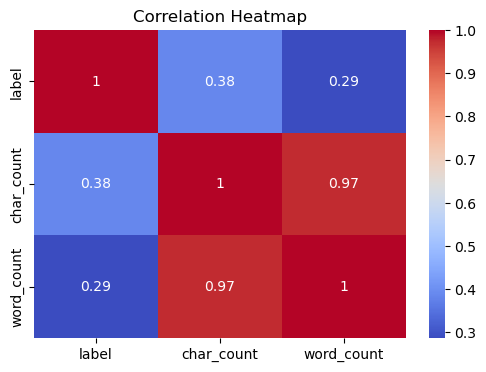

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['label','char_count','word_count']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
X = df['message']

y = df['label']

In [32]:
print(df.columns)
print(df.head())

Index(['label', 'message', 'char_count', 'word_count'], dtype='object')
   label                                            message  char_count  \
0      0  Go until jurong point, crazy.. Available only ...         111   
1      0                      Ok lar... Joking wif u oni...          29   
2      1  Free entry in 2 a wkly comp to win FA Cup fina...         155   
3      0  U dun say so early hor... U c already then say...          49   
4      0  Nah I don't think he goes to usf, he lives aro...          61   

   word_count  
0          20  
1           6  
2          28  
3          11  
4          13  


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['message']
y = df['label']

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

print(type(X))
print(X.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(5169, 8672)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 54330 stored elements and shape (4135, 8672)>

In [36]:
X_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13688 stored elements and shape (1034, 8672)>

In [37]:
y_train

2228    0
5529    0
2149    0
5058    1
5051    0
       ..
4740    0
474     0
3266    0
4016    0
879     1
Name: label, Length: 4135, dtype: int64

In [38]:
y_test

1617    0
2064    0
1272    0
3020    0
3642    0
       ..
4146    0
1208    0
4795    1
3575    0
2820    0
Name: label, Length: 1034, dtype: int64

In [39]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_pred = model.predict(X_test)

In [62]:
y_pred

array([ 0.07570456,  0.30911694,  0.00196829, ...,  1.21478547,
        0.0140993 , -0.02544116], shape=(1034,))

In [43]:
model.score(X_train,y_train)

0.9998081345818045

In [44]:
 model.score(X_test,y_test)

0.7441208979203604

In [52]:
i = model.intercept_

In [53]:
i

np.float64(0.006907454022586745)

In [54]:
c = model.coef_

In [55]:
c

array([ 0.34147458,  0.69899898,  0.01330469, ...,  0.32970747,
        0.00489999, -0.02594772], shape=(8672,))

In [56]:
"R2 Score:", r2_score(y_test,y_pred)

('R2 Score:', 0.7441208979203604)

In [57]:
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 0.07882548935400158
MSE: 0.030850592105900316


In [58]:
y_pred_class = np.where(y_pred >= 0.5, 1, 0)

accuracy = accuracy_score(y_test,y_pred_class)

print("Accuracy:", accuracy)

Accuracy: 0.9642166344294004


In [59]:
cm = confusion_matrix(
    y_test,
    y_pred_class
)

print(cm)

[[887   2]
 [ 35 110]]


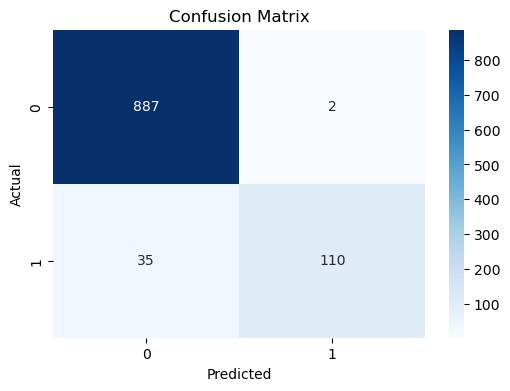

In [60]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [61]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_class
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,1,1
6,0,0
7,1,1
8,0,0
9,0,0
